# Retail Sales Data Analysis using Python (Pandas, EDA, Business Insights)

This project analyzes retail sales data using Python and Pandas to extract meaningful business insights.

The analysis includes:
- Data loading and preprocessing
- Feature engineering
- Exploratory Data Analysis (EDA)
- Data cleaning
- SQL-style joins using Pandas
- Customer and revenue analysis

Technologies used:
- Python
- Pandas
- Matplotlib

# 1. Data Loading

In [2]:
import pandas as pd

# Creating dataset
data = {
    "product": ["Laptop", "Mouse", "Keyboard", "Monitor", "Laptop", "Mouse"],
    "quantity": [1,2,1,1,1,3],
    "price": [50000,500,1500,12000,52000,500],
    "city": ["Bangalore","Mumbai","Bangalore","Delhi","Hyderabad","Chennai"],
    "order_date": [
        "2024-01-02",
        "2024-01-03",
        "2024-01-03",
        "2024-01-05",
        "2024-01-06",
        "2024-01-07"
    ]
}

df = pd.DataFrame(data)

df.head()

,product,quantity,price,city,order_date
0,Laptop,1,50000,Bangalore,2024-01-02
1,Mouse,2,500,Mumbai,2024-01-03
2,Keyboard,1,1500,Bangalore,2024-01-03
3,Monitor,1,12000,Delhi,2024-01-05
4,Laptop,1,52000,Hyderabad,2024-01-06


# 2. Feature Engineering

In [3]:
# Create revenue column
df["revenue"] = df["quantity"] * df["price"]

# Convert date column to datetime
df["order_date"] = pd.to_datetime(df["order_date"])

df.head()

,product,quantity,price,city,order_date,revenue
0,Laptop,1,50000,Bangalore,2024-01-02,50000
1,Mouse,2,500,Mumbai,2024-01-03,1000
2,Keyboard,1,1500,Bangalore,2024-01-03,1500
3,Monitor,1,12000,Delhi,2024-01-05,12000
4,Laptop,1,52000,Hyderabad,2024-01-06,52000


# 3. KPI Summary

In [4]:
# Key business metrics
total_revenue = df["revenue"].sum()
total_orders = len(df)
total_products_sold = df["quantity"].sum()
total_cities = df["city"].nunique()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Products Sold:", total_products_sold)
print("Number of Cities:", total_cities)

Total Revenue: 118000
Total Orders: 6
Total Products Sold: 9
Number of Cities: 5


# 4. Exploratory Data Analysis (EDA)

###  Revenue by Product

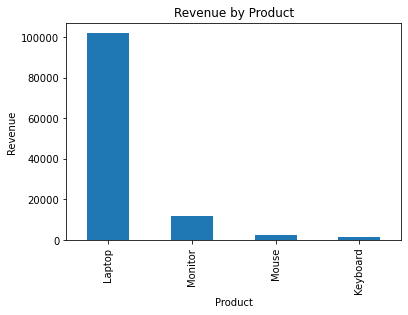

In [5]:
import matplotlib.pyplot as plt

product_revenue = df.groupby("product")["revenue"].sum().sort_values(ascending=False)

# Bar chart helps compare product performance
product_revenue.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

### Revenue by City 

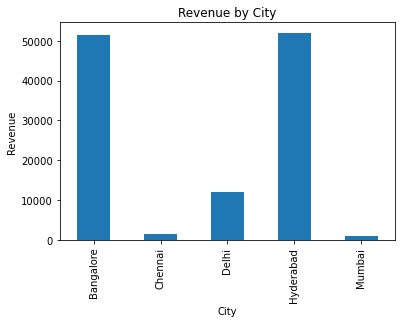

In [6]:
city_revenue = df.groupby("city")["revenue"].sum()

# Bar chart shows which cities generate highest revenue
city_revenue.plot(kind="bar")

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

###  Sales Trend Over Time

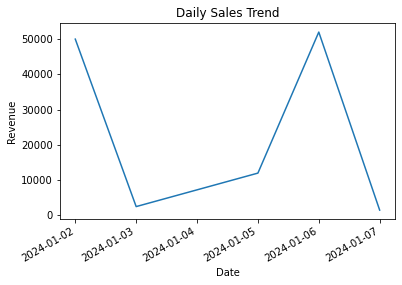

In [7]:
daily_sales = df.groupby("order_date")["revenue"].sum()

# Line chart is used to analyze trends over time
daily_sales.plot(kind="line")

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

# 5. Data Cleaning

In [8]:
# Check structure
df.info()

# Summary statistics
df.describe()

# Missing values
df.isnull().sum()

# Remove duplicates
df = df.drop_duplicates()

# Rename column for clarity
df.rename(columns={"product": "product_name"}, inplace=True)

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   product     6 non-null      object        
 1   quantity    6 non-null      int64         
 2   price       6 non-null      int64         
 3   city        6 non-null      object        
 4   order_date  6 non-null      datetime64[ns]
 5   revenue     6 non-null      int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 416.0+ bytes


,product_name,quantity,price,city,order_date,revenue
0,Laptop,1,50000,Bangalore,2024-01-02,50000
1,Mouse,2,500,Mumbai,2024-01-03,1000
2,Keyboard,1,1500,Bangalore,2024-01-03,1500
3,Monitor,1,12000,Delhi,2024-01-05,12000
4,Laptop,1,52000,Hyderabad,2024-01-06,52000


# 6. SQL-Style Joins using Pandas

### Create Customers Table 

In [9]:
customers = {
    "customer_id": [101,102,103,104],
    "customer_name": ["Rahul","Anita","Vikram","Priya"],
    "city": ["Bangalore","Mumbai","Delhi","Hyderabad"]
}

customers_df = pd.DataFrame(customers)

### Create Orders Table 

In [10]:
orders = {
    "order_id": [1,2,3,4,5],
    "customer_id": [101,102,101,105,103],
    "product_name": ["Laptop","Mouse","Keyboard","Monitor","Laptop"]
}

orders_df = pd.DataFrame(orders)

### INNER JOIN 

In [11]:
# Returns matching records in both tables
merged_df = pd.merge(orders_df, customers_df, on="customer_id", how="inner")

merged_df

,order_id,customer_id,product_name,customer_name,city
0,1,101,Laptop,Rahul,Bangalore
1,3,101,Keyboard,Rahul,Bangalore
2,2,102,Mouse,Anita,Mumbai
3,5,103,Laptop,Vikram,Delhi


### LEFT JOIN 

In [12]:
# Keeps all orders, unmatched customers become NaN
pd.merge(orders_df, customers_df, on="customer_id", how="left")

,order_id,customer_id,product_name,customer_name,city
0,1,101,Laptop,Rahul,Bangalore
1,2,102,Mouse,Anita,Mumbai
2,3,101,Keyboard,Rahul,Bangalore
3,4,105,Monitor,NaN,NaN
4,5,103,Laptop,Vikram,Delhi


 ### FULL OUTER JOIN

In [13]:
# Keeps all orders, unmatched customers become NaN
pd.merge(orders_df, customers_df, on="customer_id", how="outer")

,order_id,customer_id,product_name,customer_name,city
0,1.0,101,Laptop,Rahul,Bangalore
1,3.0,101,Keyboard,Rahul,Bangalore
2,2.0,102,Mouse,Anita,Mumbai
3,4.0,105,Monitor,NaN,NaN
4,5.0,103,Laptop,Vikram,Delhi
5,NaN,104,NaN,Priya,Hyderabad


# 7. Customer Analysis

### Orders per Customer

In [14]:
customer_orders = merged_df.groupby("customer_name")["order_id"].count()

customer_orders

customer_name
Anita     1
Rahul     2
Vikram    1
Name: order_id, dtype: int64

### Top Customer 

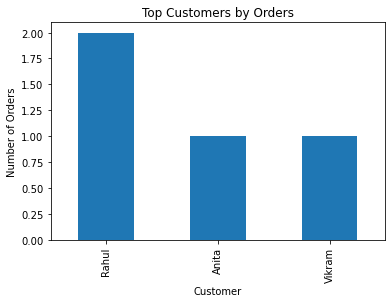

In [15]:
top_customers = customer_orders.sort_values(ascending=False)

# Bar chart shows most active customers
top_customers.plot(kind="bar")

plt.title("Top Customers by Orders")
plt.xlabel("Customer")
plt.ylabel("Number of Orders")
plt.show()

### Revenue by Customer

In [16]:
# Map revenue to merged dataframe
merged_df["revenue"] = df["revenue"]

customer_revenue = merged_df.groupby("customer_name")["revenue"].sum().sort_values(ascending=False)

customer_revenue

customer_name
Rahul     51000
Vikram    12000
Anita      1500
Name: revenue, dtype: int64

# 8. Final Business Insights

### Key Insights:

1. Laptop contributes the majority of revenue due to its high price.
2. Hyderabad generated the highest single-order revenue.
3. Bangalore has the highest number of orders.
4. Electronics category dominates overall sales.
5. Sales trends show spikes when high-value products are sold.
6. Rahul is the top customer based on both order frequency and revenue.
7. Some orders have missing customer information, indicating data quality issues.